# Finding the Second- and Third-Order Winners of an Oil Price Increase

### A derivative-exposure screen of the TSX Top 150

When oil prices rise, the obvious names move first: producers, refiners, airlines. Those are **first derivative** exposures, and they are already priced by the time most investors act.

The harder question is what happens *next*. Airlines cut capacity to defend margins, which lifts the survivors' pricing power. Households absorb higher fuel bills and trade down at the grocery store, which shifts share toward discount retail. These **second** and **third derivative** exposures sit in companies that no oil screen would ever surface — and that is exactly where the unpriced opportunity tends to live.

This notebook builds that map automatically and tests it against real disclosure. It:

1. **Grounds** the theme in current market evidence from [Bigdata.com](https://bigdata.com)
2. **Builds a mindmap** of exposure pathways, organised into three derivative hops
3. **Searches** filings, earnings calls, and premium news for each pathway across the portfolio
4. **Classifies** every retrieved quote and attributes it to a company and a pathway
5. **Summarises** each exposed company and exports the evidence pack

Every conclusion below traces back to a dated, attributable quote from a primary document.

## Environment

The pipeline logic lives in the `src` package; this notebook only orchestrates and presents it. Two credentials are read from the project `.env` file: `BIGDATA_API_KEY` for evidence retrieval and `OPENAI_API_KEY` for taxonomy generation and classification.

The cell below also switches the working directory to the project root so relative paths resolve the same way they do for the command-line tool.

In [1]:
from __future__ import annotations

import json
import os
import textwrap
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
os.chdir(PROJECT_ROOT)
load_dotenv(PROJECT_ROOT / ".env")

from src import screener, viz
from src.derivative_grounding import collect_grounding, format_grounding_brief, write_grounding
from src.derivative_taxonomy import derivative_preview, validate_derivatives_taxonomy
from src.modes import AnalysisMode, get_profile
from src.notebook_support import preview_quote, quiet_output
from src.prompts import DERIVATIVE_BRANCH_LABELS, TAXONOMY_STYLE_DERIVATIVES
from src.run_context import RunContext

pd.set_option("display.max_colwidth", 110)
%matplotlib inline

print(f"Project root: {PROJECT_ROOT}")
print(f"Bigdata.com credentials loaded: {bool(os.getenv('BIGDATA_API_KEY'))}")
print(f"OpenAI credentials loaded:      {bool(os.getenv('OPENAI_API_KEY'))}")

Project root: /Users/franciscogomez/git/bigdata/bigdata-cookbook/Thematic_Screener_CLI
Bigdata.com credentials loaded: True
OpenAI credentials loaded:      True


## Defining the screen

Four inputs define the analysis:

| Input | Purpose |
|---|---|
| **Theme** | The shock whose consequences we trace outward |
| **Analyst focus** | Steers the mindmap toward hidden, indirect exposures rather than the obvious energy names |
| **Universe** | The 150 largest TSX listings — the portfolio we are screening |
| **Window** | The publication period searched for evidence |

`RETRIEVAL_DEPTH` sets how deeply each pathway samples its available evidence pool. A deeper sample yields more quotes per pathway and a longer run; 1% is ample for a screen of this size.

Every artefact is written to an isolated run directory, so this analysis can be reproduced, audited, or resumed from the command line later.

In [2]:
MAIN_THEME = "Oil price increase"
ANALYST_FOCUS = (
    "Hidden 1st/2nd/3rd derivative exposures in a TSX portfolio: direct fuel and "
    "commodity P&L, second-hop capacity and pricing responses, and third-hop "
    "consumer mix-shift into sectors not obviously tied to energy."
)
UNIVERSE_PATH = PROJECT_ROOT / "tsx_top150_rp_entities.csv"
START_DATE = "2025-06-01"
END_DATE = "2026-06-09"
RETRIEVAL_DEPTH = 0.05

RUN_NAME = "tsx_oil_derivatives"
MODE = AnalysisMode.THEMATIC_SCREENER.value
profile = get_profile(MODE)

context = RunContext.create(PROJECT_ROOT / "runs", RUN_NAME)
context.ensure_run_dir()
context.save_config(
    {
        "mode": MODE,
        "main_theme": MAIN_THEME,
        "analyst_focus": ANALYST_FOCUS,
        "universe": str(UNIVERSE_PATH),
        "start_date": START_DATE,
        "end_date": END_DATE,
        "taxonomy_style": TAXONOMY_STYLE_DERIVATIVES,
        "chunk_percentage": RETRIEVAL_DEPTH,
    }
)

print(f"Theme:  {MAIN_THEME}")
print(f"Window: {START_DATE} to {END_DATE}")
print(f"Run directory: {context.run_dir}")

Theme:  Oil price increase
Window: 2025-06-01 to 2026-06-09
Run directory: /Users/franciscogomez/git/bigdata/bigdata-cookbook/Thematic_Screener_CLI/runs/tsx_oil_derivatives


## The portfolio under review

The universe is the screening perimeter: every claim in this report is about one of these companies. Each row pairs a company name with the entity identifier used to attribute retrieved documents, which is what allows a quote buried in a filing to be tied back to a specific holding.

In [3]:
universe_df = screener.load_universe(UNIVERSE_PATH)
company_ids = universe_df[screener.UNIVERSE_ID_COLUMN].tolist()

print(f"{len(universe_df)} companies in the screening universe\n")
universe_df.head(8)

150 companies in the screening universe



,RP_ENTITY_ID,COMPANY_NAME
0,020E33,Royal Bank of Canada Inc.
1,736B94,Shopify Inc.
2,741768,Toronto-Dominion Bank Inc.
3,930367,Bank of Montreal Inc.
4,513791,Enbridge Inc.
5,9B42DD,Agnico Eagle Mines Ltd.
6,53C167,Bank of Nova Scotia Co.
7,B7F5B8,Canadian Imperial Bank of Commerce Co.


## Step 1 — Ground the theme in market evidence

Before proposing any exposure pathway, we ask the market what is actually happening. Three searches run against [Bigdata.com](https://bigdata.com), one per derivative hop:

- **First hop** — how higher oil directly moves company costs and revenues
- **Second hop** — how companies *respond*: capacity cuts, repricing, hedging
- **Third hop** — knock-on consumer and demand shifts in unrelated sectors

These searches deliberately run **without a universe filter**. We want to learn the shape of the transmission chain from the global corpus of filings, transcripts, and premium news, not just from what our 150 companies happen to have said. The resulting briefing is fed into the mindmap step so the taxonomy reflects observed behaviour rather than textbook theory.

In [4]:
with quiet_output():
    grounding = collect_grounding(
        MAIN_THEME,
        start_date=START_DATE,
        end_date=END_DATE,
        max_chunks_per_hop=8,
    )
write_grounding(context.grounding_path, grounding)
grounding_brief = format_grounding_brief(grounding)

for hop in grounding["hops"]:
    print(f"{hop['branch']}: {len(hop['chunks'])} supporting passages")

1st derivative: 8 supporting passages
2nd derivative: 8 supporting passages
3rd derivative: 8 supporting passages


### What the market is saying

The table below lists the sourced passages behind each hop. Note the mix of document types: SEC filings describing fuel-cost pass-through, earnings calls where management explains a capacity response, and news coverage of consumer behaviour. This is the raw material the mindmap is built from.

Source text is shown as a short lead-in only; the full passages are written to the run directory as `grounding.json`.

In [5]:
grounding_rows = [
    {
        "hop": hop["branch"],
        "source": chunk["source_name"],
        "date": str(chunk["timestamp"])[:10],
        "passage": preview_quote(chunk["text"]),
    }
    for hop in grounding["hops"]
    for chunk in hop["chunks"][:3]
]
pd.DataFrame(grounding_rows)

,hop,source,date,passage
0,1st derivative,Quartr Reports,2026-02-26,We could experience periods of higher costs if commodity prices rise. These increases could …
1,1st derivative,Edgar SEC Filings,2025-10-09,"acceptable to our customers, these customers could reduce purchases of our products and increase …"
2,1st derivative,Benzinga,2026-03-09,"""It also influences the many tech companies that are building out energy-intensive AI data …"
3,2nd derivative,Benzinga,2026-05-21,Your next question comes from Eddie Wong with Morgan Stanley. Please go ahead. March …
4,2nd derivative,PubT,2026-04-02,"Now on slide 13, let me walk you through the recent actions we've taken …"
5,2nd derivative,PubT,2026-05-27,Knock-on Effect Of Rising Oil Prices The impact of rising energy prices is also …
6,3rd derivative,PubT,2026-05-27,Knock-on Effect Of Rising Oil Prices The impact of rising energy prices is also …
7,3rd derivative,PubT,2026-05-06,"Against a backdrop of shifting valuations and renewed deal activity, we brought together leaders …"
8,3rd derivative,Benzinga,2026-04-14,"Information technology, financial, and consumer discretionary equities logged the largest gains Monday as ..."


## Step 2 — Build the derivative mindmap

The grounded briefing is now turned into a structured taxonomy: one root theme, three derivative branches, and a set of concrete **exposure pathways** beneath each.

A pathway is not a sector label — it is a specific economic mechanism by which a company gains or loses from the theme. "Airline capacity discipline" is a pathway; "transportation" is not. Each pathway also carries its own retrieval query, written in the voice of a disclosure document so it matches how companies actually describe themselves in filings and on calls.

The validation step confirms the tree has the required three-hop shape and that second- and third-hop queries are genuinely distinct from first-hop ones, rather than restating the original shock.

In [6]:
with quiet_output():
    root = screener.generate_taxonomy(
        main_theme=MAIN_THEME,
        analyst_focus=ANALYST_FOCUS,
        profile=profile,
        taxonomy_style=TAXONOMY_STYLE_DERIVATIVES,
        grounding_brief=grounding_brief,
        print_taxonomy=False,
    )

labels, search_queries = screener.write_taxonomy_artifacts(
    root,
    themes_path=context.themes_path,
    search_queries_path=context.search_queries_path,
    taxonomy_tree_path=context.taxonomy_tree_path,
    profile=profile,
)
findings = validate_derivatives_taxonomy(root)
preview = derivative_preview(root)

for branch, branch_leaves in preview.items():
    print(f"{branch}: {len(branch_leaves)} pathways")
print(f"\nTotal exposure pathways: {len(labels)}")
print(f"Structural validation: {'passed' if not findings else findings}")

1st derivative: 4 pathways
2nd derivative: 4 pathways
3rd derivative: 4 pathways

Total exposure pathways: 12
Structural validation: passed


### The exposure map

Read this left to right: the theme fans out into three hops, each hop into its pathways. Distance from the root is distance from the obvious trade. The first-hop names are the consensus view; the third-hop pathways on the right are where a screen like this earns its keep.

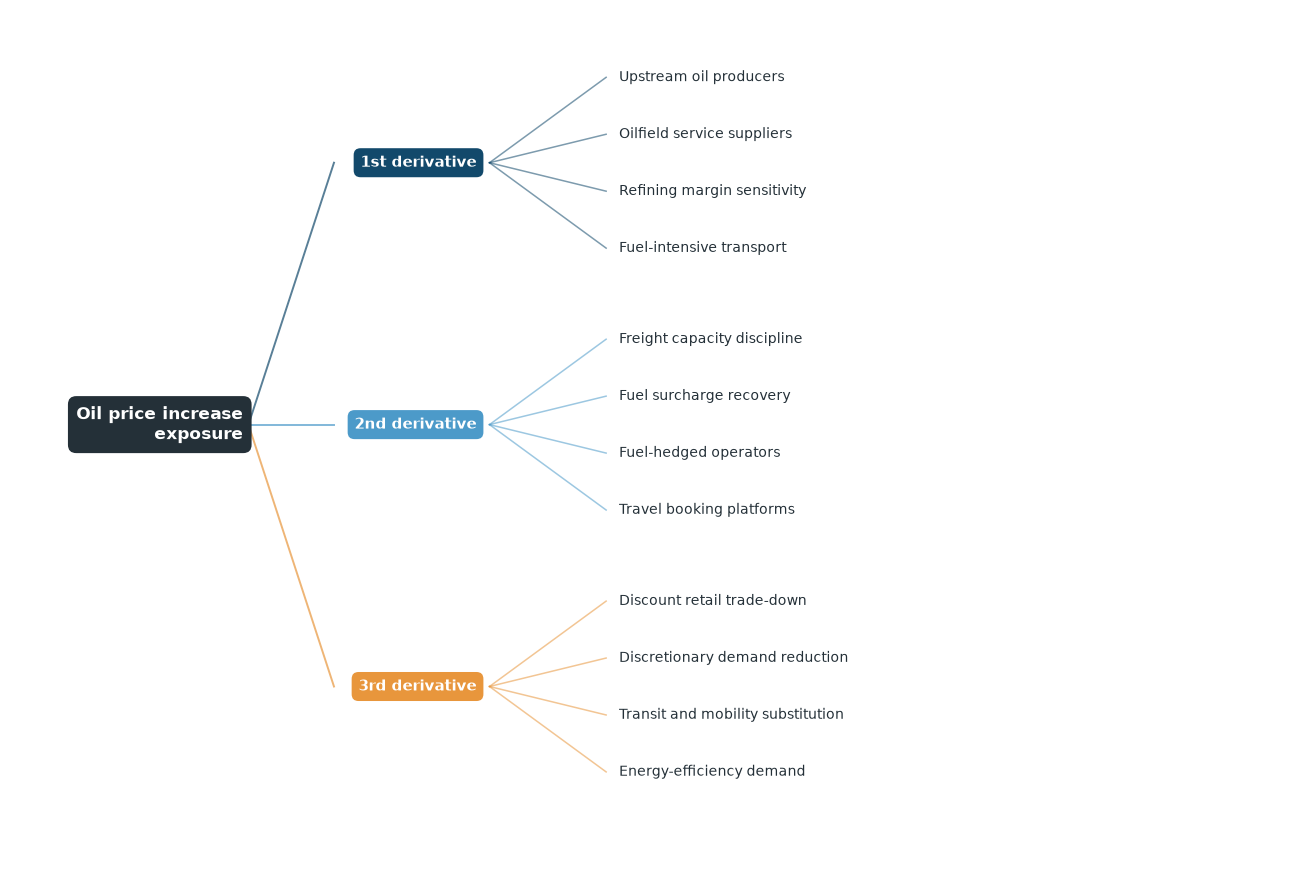

In [7]:
viz.plot_mindmap(root);

### The search behind each pathway

Each pathway is paired with the document-voice query used to find matching disclosure. These read like sentences a company would write about itself, which is what makes them effective against filings and transcripts.

In [8]:
hop_by_label = {
    leaf: branch for branch, leaves in preview.items() for leaf in leaves
}
pd.DataFrame(
    {
        "hop": [hop_by_label.get(label, "") for label in labels],
        "pathway": labels,
        "retrieval query": search_queries,
    }
).sort_values("hop").reset_index(drop=True)

,hop,pathway,retrieval query
0,1st derivative,Upstream oil producers,The company explores for and produces crude oil and reports realized prices from its production volumes.
1,1st derivative,Oilfield service suppliers,"The company provides drilling, completion, equipment, or field services to oil and gas producers."
2,1st derivative,Refining margin sensitivity,"The company purchases crude oil and processes it into gasoline, diesel, jet fuel, or other refined products."
3,1st derivative,Fuel-intensive transport,"The company consumes jet fuel, diesel, or marine fuel to operate passenger, freight, or logistics networks."
4,2nd derivative,Freight capacity discipline,"The company reduces routes, frequencies, fleet utilization, or available capacity to protect operating mar..."
5,2nd derivative,Fuel surcharge recovery,"The company applies fuel surcharges, indexed contracts, or rate increases to recover transportation costs ..."
6,2nd derivative,Fuel-hedged operators,"The company enters fuel swaps, collars, forward contracts, or fixed-price supply agreements for planned co..."
7,2nd derivative,Travel booking platforms,"The company earns commissions, booking fees, or merchant revenue from airline, hotel, or vacation reservat..."
8,3rd derivative,Discount retail trade-down,"The company sells value-priced merchandise and reports traffic, private-label, or lower-priced product gro..."
9,3rd derivative,Discretionary demand reduction,"The company reports weaker demand, postponed purchases, or reduced volumes for discretionary products."


## Step 3 — Turn each pathway into a targeted search

Each pathway becomes its own search plan across all 150 companies and the full date window. Plans are built rather than executed blindly: the planner measures how much matching content exists per company and splits the work into batches sized to the available evidence, so heavily covered names do not crowd out thinly covered ones.

This is what keeps a third-hop pathway like discount retail from being drowned out by the volume of oil-producer coverage.

In [9]:
context.ensure_plans_dir()
with quiet_output():
    plan_paths = screener.build_plans(
        labels=labels,
        search_queries=search_queries,
        company_ids=company_ids,
        plans_dir=context.plans_dir,
        start_date=START_DATE,
        end_date=END_DATE,
    )

print(f"Built {len(plan_paths)} search plans covering {len(company_ids)} companies each.")

Built 12 search plans covering 150 companies each.


## Step 4 — Retrieve the evidence

The plans now execute against filings, earnings transcripts, and premium news. Results are deduplicated across pathways, so a document that matches two pathways is stored once and counted once.

This is the longest step in the notebook, and the only one that touches the document corpus at scale.

In [10]:
with quiet_output():
    documents = screener.run_search(
        plans_dir=context.plans_dir,
        chunk_percentage=RETRIEVAL_DEPTH,
    )

context.ensure_results_dir()
with context.results_path.open("w", encoding="utf-8") as handle:
    json.dump(documents, handle, default=str)

retrieved_passages = sum(len(document.get("chunks", [])) for document in documents)
print(f"Retrieved {len(documents):,} unique documents")
print(f"Containing {retrieved_passages:,} candidate passages")

Retrieved 1,550 unique documents
Containing 1,986 candidate passages


## Step 5 — Classify every passage

Retrieval finds text that *looks* relevant; classification decides whether it genuinely evidences exposure. Each passage is assessed against the pathway set and assigned one pathway, a materiality rating, and a written rationale.

The classifier is deliberately strict about derivative hops. A passage that merely mentions oil is not enough to earn a second- or third-hop label — the text must evidence the actual mechanism, such as a capacity decision, a hedging programme, or a shift in consumer mix. Anything ambiguous is discarded rather than counted, which is why the retained figure below is well short of the candidate pool.

In [11]:
sentences = screener.extract_sentences(documents, universe_df)

with quiet_output():
    classifications = screener.label_sentences(
        sentences=sentences,
        main_theme=MAIN_THEME,
        analyst_focus=ANALYST_FOCUS,
        labels=labels,
        profile=profile,
        taxonomy_root=root,
    )

labeled_df = screener.build_labeled_dataframe(sentences, classifications)
labeled_df.to_csv(context.labeled_sentences_path, index=False)
evidence_df = viz.attach_hop_column(labeled_df, root)

print(f"Passages assessed: {len(sentences):,}")
print(f"Confirmed exposure evidence: {len(evidence_df):,}")
print(f"Companies with confirmed exposure: {evidence_df['company_name'].nunique()}")

Passages assessed: 1,986
Confirmed exposure evidence: 433
Companies with confirmed exposure: 63


## Where the exposure sits

The first chart pair answers the structural question: how much evidence did each hop produce, and how many distinct companies does it touch?

The two panels usually tell different stories. First-hop exposure tends to be *deep* — a lot of evidence concentrated in a handful of energy names. Later hops tend to be *broad* — less evidence per company, but spread across more of the portfolio. A wide third-hop bar on the right panel means the theme reaches further into the book than an energy screen would suggest.

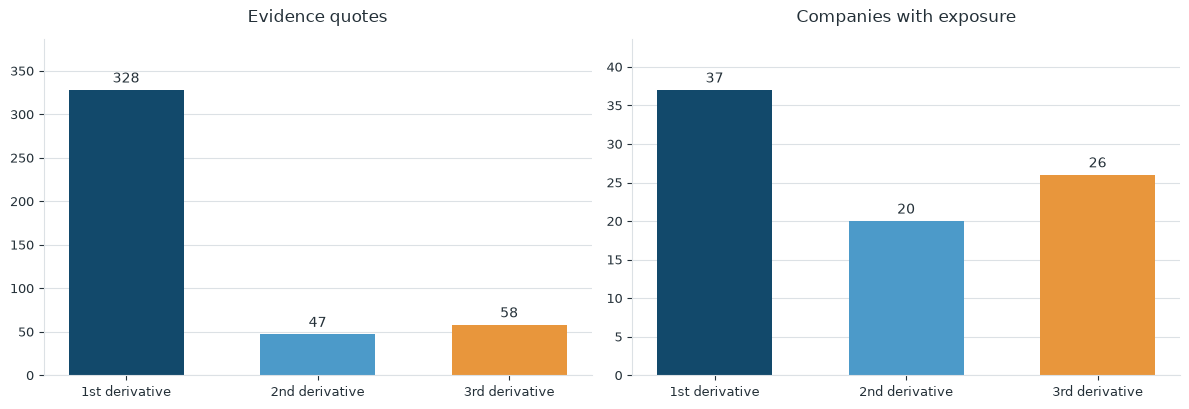

In [12]:
viz.plot_hop_coverage(evidence_df);

### Which pathways carry the evidence

Ranking pathways by evidence volume shows where the transmission chain is currently active. Bars are coloured by hop, so a highly ranked amber or mid-blue bar is a signal worth attention: it means an indirect mechanism is showing up in disclosure as strongly as the direct ones.

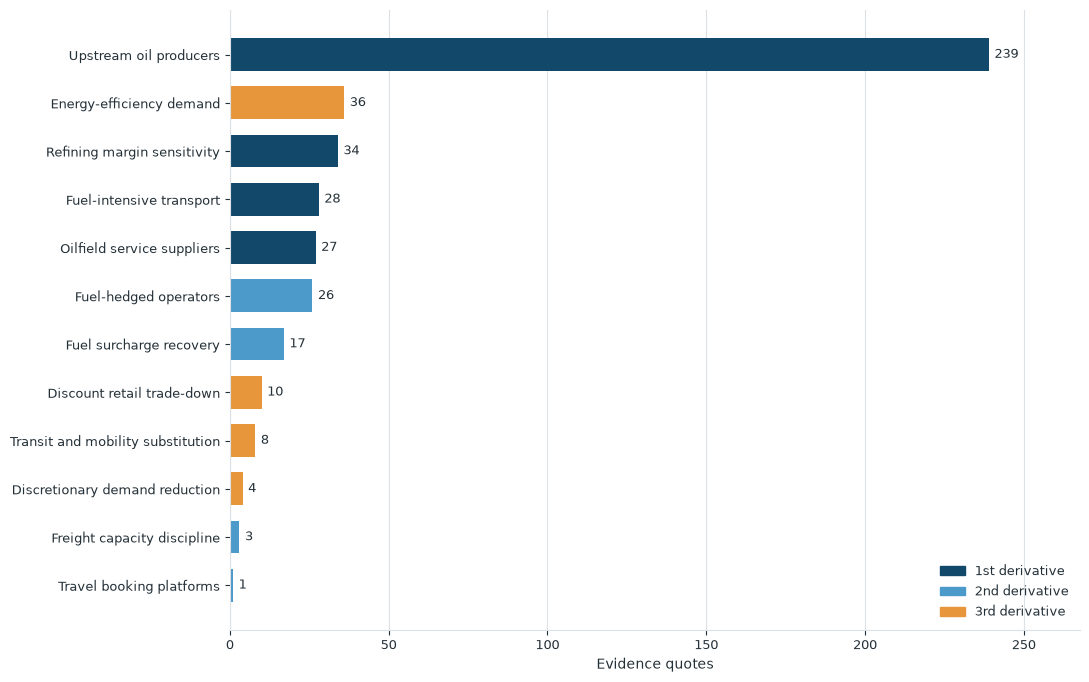

In [13]:
viz.plot_top_pathways(evidence_df);

### The most exposed companies

Each bar is one holding, segmented by the hops its evidence came from. The segmentation is the useful part: a bar that is entirely dark blue is a conventional energy exposure, while a bar with mid-blue or amber is a company whose sensitivity to oil runs through a less obvious channel.

Read this as the *consensus* view. Ranking by evidence volume favours direct exposure, because an oil producer discusses crude prices on every call while a retailer mentions fuel-driven trade-down once a year. The indirect names are therefore almost absent here by construction — the next chart ranks them on their own terms.

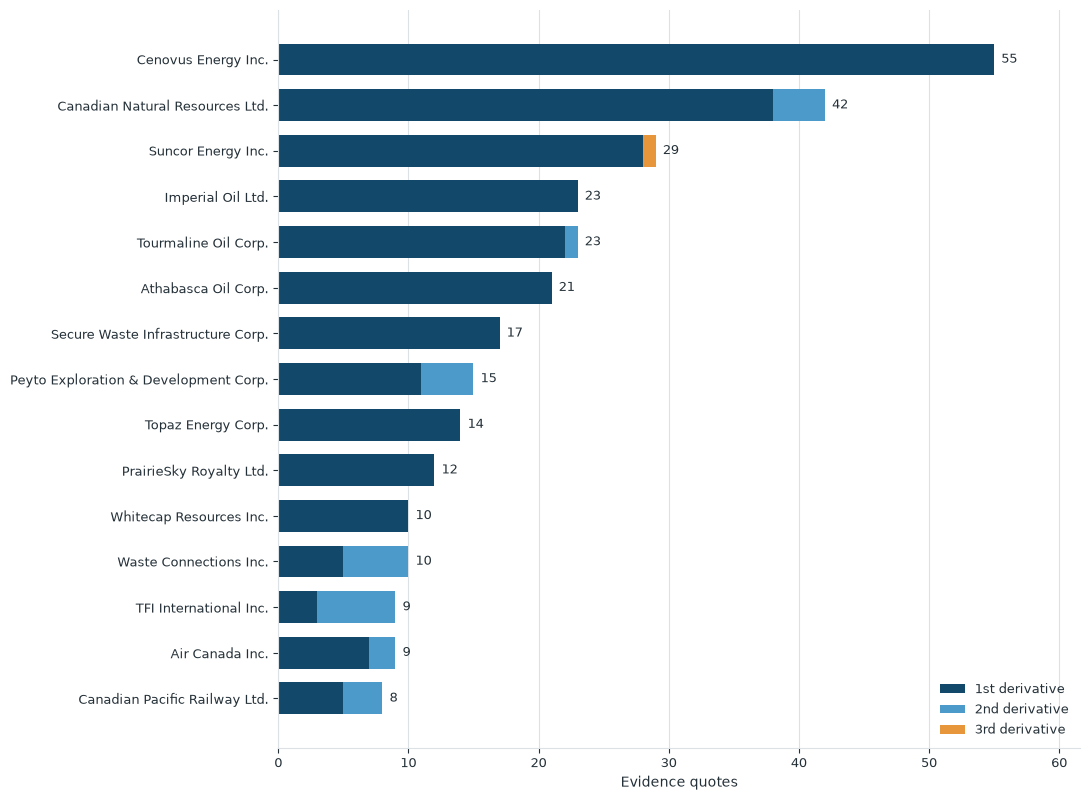

In [14]:
viz.plot_top_companies(evidence_df);

### Where the indirect exposure sits

This matrix drops direct exposure entirely and ranks companies on second- and third-hop evidence alone, so the later channels are no longer competing against producer disclosure volume for a place in the chart.

The second-hop column is dominated by operating responses to higher fuel costs — waste haulage, gold miners running diesel fleets, airlines and railroads. The third-hop column is a different list entirely: banks, infrastructure, and engineering names reached through consumer and investment behaviour rather than through fuel at all. Those are the holdings no energy screen would return.

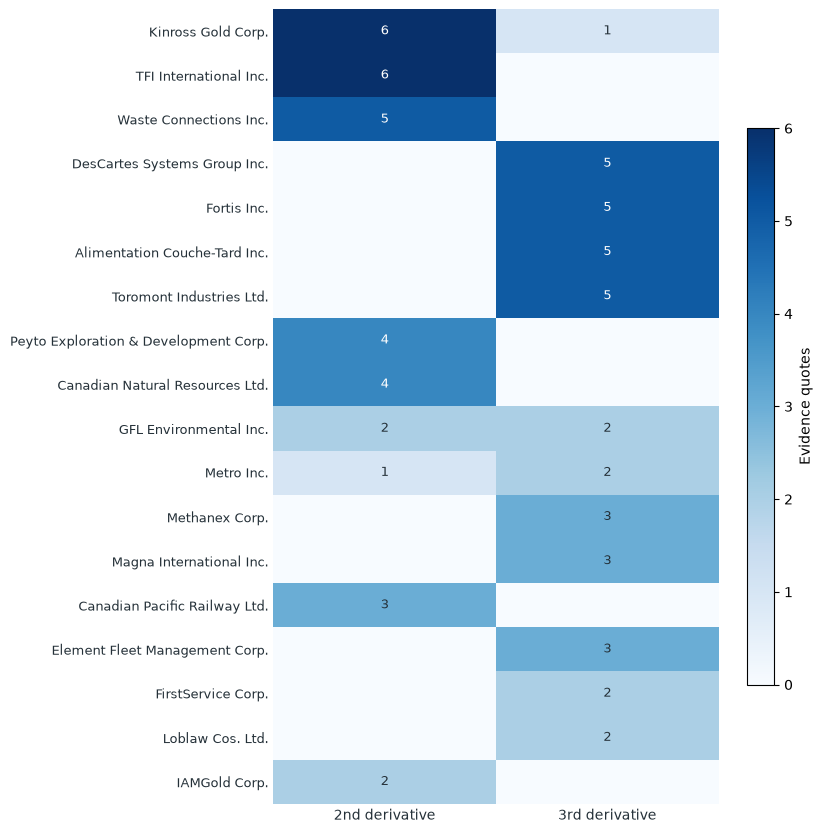

In [15]:
viz.plot_company_hop_matrix(evidence_df, hops=viz.INDIRECT_HOPS);

### How the story developed

Evidence plotted by publication month. Because filings and earnings calls cluster around reporting dates, some seasonality is expected. What matters is the *composition* over time: later hops appearing more prominently in recent months indicates the shock is still working its way through the chain rather than having fully played out.

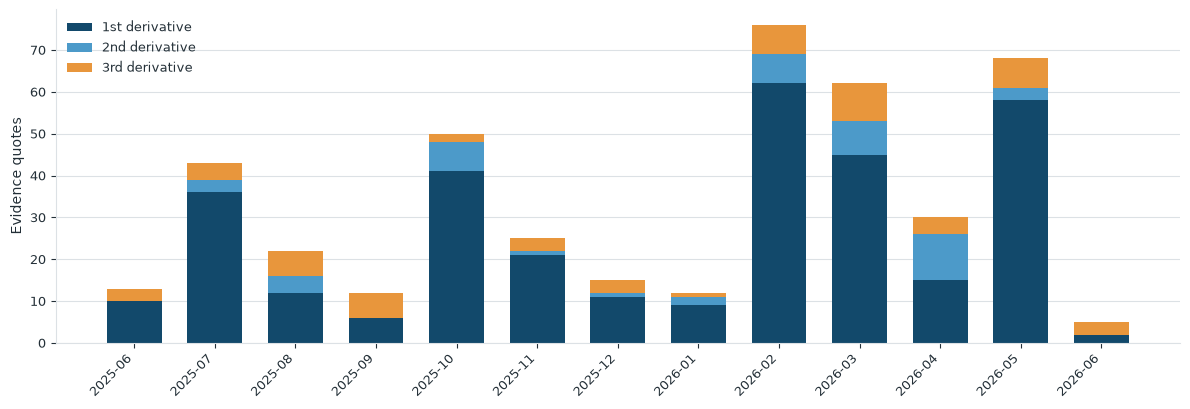

In [16]:
viz.plot_evidence_timeline(evidence_df);

## The non-obvious names

This is the core output of the screen. The table isolates companies whose exposure is **entirely** second- or third-hop — holdings with no direct oil linkage at all, which would not appear in any conventional energy screen, yet have disclosed evidence of sensitivity to the theme.

Each row shows the pathway carrying the exposure and the opening words of the quote behind it, so the reasoning can be checked immediately. The complete quote, its source, and its date sit in the exported workbook and in `labeled_sentences.csv`.

In [17]:
FIRST_HOP = DERIVATIVE_BRANCH_LABELS[0]

hops_per_company = evidence_df.groupby("company_name")["hop"].agg(set)
indirect_only = [
    company for company, hops in hops_per_company.items() if hops and FIRST_HOP not in hops
]

indirect_df = (
    evidence_df[evidence_df["company_name"].isin(indirect_only)]
    .sort_values(["company_name", "hop"])
    .groupby("company_name")
    .first()
    .reset_index()
)
indirect_df["quotes"] = indirect_df["company_name"].map(
    evidence_df["company_name"].value_counts()
)
indirect_df["evidence"] = indirect_df["text"].map(preview_quote)

print(f"{len(indirect_only)} companies are exposed only through indirect channels.\n")
indirect_df.sort_values("quotes", ascending=False)[
    ["company_name", "hop", "label", "quotes", "evidence"]
].head(12).reset_index(drop=True)

26 companies are exposed only through indirect channels.



,company_name,hop,label,quotes,evidence
0,Kinross Gold Corp.,2nd derivative,Fuel-hedged operators,7,"|(a)|Upon maturity of these contracts, the amounts in OCI before taxes will reverse against …"
1,Fortis Inc.,3rd derivative,Energy-efficiency demand,5,"In addition, FortisBC started to offer advanced demand side management rebates for customers in …"
2,DesCartes Systems Group Inc.,3rd derivative,Discretionary demand reduction,5,"Increases in fuel prices, driver shortages and other increased transportation costs may have an …"
3,GFL Environmental Inc.,2nd derivative,Fuel surcharge recovery,4,"In terms of fuel, diesel costs in the quarter were up nearly 10% year-over-year …"
4,Metro Inc.,2nd derivative,Fuel surcharge recovery,3,"And then just on the fuel cost increases, I know you mentioned in your …"
5,Methanex Corp.,3rd derivative,Transit and mobility substitution,3,"""These partnerships allow us to safely and reliably fuel ships with methanol in two …"
6,Element Fleet Management Corp.,3rd derivative,Energy-efficiency demand,3,About Element Fleet Management Element Fleet Management (TSX:EFN) is the largest publicly traded pure-play …
7,Magna International Inc.,3rd derivative,Discretionary demand reduction,3,"Overall vehicle sales levels are significantly affected by changes in consumer confidence levels, which …"
8,AtkinsRéalis Group Inc.,3rd derivative,Energy-efficiency demand,2,"As part of the Alto, will connect seven cities district that integrates energy-efficient enhance …"
9,BRP Inc.,3rd derivative,Energy-efficiency demand,2,Water Taxi Market Competitive Landscape: Top Players Driving Innovation & Waterfront Transit Growth Compet...


## Step 6 — Company narratives

Individual quotes are the audit trail; the investment case needs a synthesis. This step consolidates all confirmed evidence for each company into a single narrative explaining how that business is exposed to the theme.

These summaries are written only from evidence retained in the previous step, so they cannot introduce claims the documents do not support.

In [18]:
with quiet_output():
    summaries_df = screener.summarize_companies(
        merged_df=labeled_df,
        main_theme=MAIN_THEME,
        profile=profile,
    )
summaries_df.to_csv(context.company_summaries_path, index=False)

screener_df = screener.build_screener_dataframe(labeled_df, summaries_df)
screener_df.to_csv(context.screener_results_path, index=False)

print(f"Wrote narratives for {len(summaries_df)} companies.")

Wrote narratives for 63 companies.


### Narratives for the most exposed holdings

The five companies with the most supporting evidence, with their exposure channels noted above each narrative.

In [19]:
top_companies = evidence_df["company_name"].value_counts().head(5)
summary_lookup = dict(zip(summaries_df["company_name"], summaries_df["summary"]))

for company, quote_count in top_companies.items():
    company_hops = sorted(set(evidence_df.loc[evidence_df["company_name"] == company, "hop"].dropna()))
    print(f"{company}  —  {quote_count} quotes  —  {', '.join(company_hops)}")
    narrative = summary_lookup.get(company, "No narrative generated.")
    print(textwrap.fill(str(narrative), width=100, initial_indent="  ", subsequent_indent="  "))
    print()

Cenovus Energy Inc.  —  55 quotes  —  1st derivative
  Cenovus has material direct exposure to higher oil prices through its large upstream business,
  including oil sands, thermal, conventional and offshore crude production, with substantial volumes
  sold into North American and global markets. Its integrated Canadian and U.S. refining and
  upgrading operations further link earnings to crude differentials, feedstock costs, crack spreads
  and refined-product pricing across gasoline, diesel, jet fuel, asphalt and synthetic crude.
  Integration, storage, transportation, hedging, product-mix management and refinery run-rate
  optimization can mitigate volatility and improve value capture, but the primary effects remain
  upstream commodity revenue sensitivity and downstream refining-margin exposure.

Canadian Natural Resources Ltd.  —  42 quotes  —  1st derivative, 2nd derivative
  Canadian Natural Resources Ltd. has substantial direct exposure to higher oil prices as a major
  upstrea

## Step 7 — The deliverable pack

The run is exported in two formats. The Excel workbook is the working document for an analyst: labelled evidence, company narratives, a company-by-pathway scoring grid, and the taxonomy itself, each on its own sheet. The JSON report carries the same content in the schema used by the Bigdata.com visualisation app.

Both sit alongside the intermediate artefacts in the run directory, so any number in this notebook can be traced back to the document it came from.

In [20]:
report = screener.build_report_json(screener_df, root, universe_df, MODE)
with context.report_json_path.open("w", encoding="utf-8") as handle:
    json.dump(report, handle, indent=2, default=str)

excel_path = screener.export_excel(
    screener_df=screener_df,
    company_summaries_df=summaries_df,
    root=root,
    path=context.report_excel_path,
)

for artefact in sorted(context.run_dir.glob("*")):
    if artefact.is_file():
        print(f"{artefact.name:<28} {artefact.stat().st_size / 1024:>8.1f} KB")

company_summaries.csv            39.6 KB
config.json                       0.5 KB
grounding.json                   32.5 KB
labeled_sentences.csv           880.4 KB
report.json                    1028.6 KB
report.xlsx                     337.1 KB
screener_results.csv           1208.4 KB
search_queries.txt                1.3 KB
taxonomy_tree.json                5.5 KB
themes.txt                        0.3 KB


### The screen output

The ranked screen, which is the sheet an analyst works from. Each row carries the company, the number of confirmed evidence quotes behind it, the derivative channels that evidence arrived through, and the pathway contributing most of it.

The workbook expands this into the full grid — every company scored against every individual pathway — alongside the underlying quotes.

In [21]:
scoring_df = screener.build_company_scoring_df(screener_df)

screen = (
    evidence_df.groupby("company_name")
    .agg(
        quotes=("sentence_id", "count"),
        channels=("hop", lambda hops: ", ".join(sorted(set(hops.dropna())))),
        lead_pathway=("label", lambda labels: labels.value_counts().index[0]),
    )
    .sort_values("quotes", ascending=False)
    .reset_index()
)

print(f"Full grid in the workbook: {len(scoring_df)} companies x {len(labels)} pathways\n")
screen.head(15)

Full grid in the workbook: 63 companies x 12 pathways



,company_name,quotes,channels,lead_pathway
0,Cenovus Energy Inc.,55,1st derivative,Upstream oil producers
1,Canadian Natural Resources Ltd.,42,"1st derivative, 2nd derivative",Upstream oil producers
2,Suncor Energy Inc.,29,"1st derivative, 3rd derivative",Upstream oil producers
3,Imperial Oil Ltd.,23,1st derivative,Upstream oil producers
4,Tourmaline Oil Corp.,23,"1st derivative, 2nd derivative",Upstream oil producers
5,Athabasca Oil Corp.,21,1st derivative,Upstream oil producers
6,Secure Waste Infrastructure Corp.,17,1st derivative,Oilfield service suppliers
7,Peyto Exploration & Development Corp.,15,"1st derivative, 2nd derivative",Upstream oil producers
8,Topaz Energy Corp.,14,1st derivative,Upstream oil producers
9,PrairieSky Royalty Ltd.,12,1st derivative,Upstream oil producers


## Reusing this analysis

The screen is theme-agnostic. Changing `MAIN_THEME` and `ANALYST_FOCUS` at the top and re-running produces the same three-hop treatment of any shock — a tariff regime, a rate cut, a regulatory change — against any universe supplied as a CSV of entity identifiers.

The identical workflow is available from the command line, which is the better route for scheduled or batch runs:

```bash
uv run python -m src.cli run-all \\
  --run-name tsx_oil_derivatives \\
  --taxonomy-style derivatives \\
  --ground-with-bigdata \\
  --main-theme "Oil price increase" \\
  --analyst-focus "Hidden 1st/2nd/3rd derivative exposures in a TSX portfolio" \\
  --universe tsx_top150_rp_entities.csv
```

Because this notebook writes to the same run directory, a session started here can be continued from the command line, and vice versa.